## NB4 — ROGUE Purity Audit per (sample, K, GEP)

**Pipeline: NB1 → NB2 → NB4.** NB1 (`1_gsea_celltype_annotation.ipynb`) scores every GEP against the reference cell types via GSEA. NB2 (`2_celltype_gated_correlation.ipynb`) turns those scores into one label per (K, GEP) — `per_gep_labels.tsv`. This notebook consumes that file: it assigns each cell to its argmax GEP, computes ROGUE per (sample, K, GEP) on the cNMF HVG substrate, and asks whether the GEP is a purer grouping than the original annotation its label points to.

(NB3 is a separate, full-transcriptome purity check on the original annotations themselves — not a direct input here.)

#### Split/merge logic

Each row's `membership_label` picks a baseline:

* **Specific** (e.g. `cDC2_CD1C`): baseline = HVG ROGUE of the original `cDC2_CD1C` cells in that sample. Δ ROGUE > 0 → evidence for **splitting** the label.
* **Subgroup** (e.g. `Mono_CD14+Mono_CD14_IL1B`): baseline = HVG ROGUE of just those constituent labels pooled. Beating the best single constituent → evidence for **merging that subset**.
* **Family** (e.g. `Monocyte_family`): baseline = HVG ROGUE of all constituent labels pooled. Beating the best single constituent → evidence for **merging the full family**.
* **Ambiguous/Mixed**: no baseline; reported standalone.

#### Gene space
Everything here — GEP scores and baselines — is computed on the same HVG space of cNMF substrate, so Δ ROGUE is comparable within this notebook. Absolute values run lower than NB3's full-transcriptome scores; don't compare them to the 0.9 threshold from Liu et al. (2020).

**Reference:** Liu et al., *Nat Commun* (2020). https://github.com/PaulingLiu/ROGUE

In [1]:
import os
os.environ['R_HOME'] = '/Library/Frameworks/R.framework/Resources'
import glob
import re
import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import sparse
import time
from tqdm.auto import tqdm
import warnings
warnings.filterwarnings('ignore')

import rpy2.robjects as ro
from rpy2.robjects import pandas2ri, numpy2ri
from rpy2.robjects.packages import importr

CONVERTER = ro.default_converter + pandas2ri.converter + numpy2ri.converter

rogue_r = importr('ROGUE')
tibble  = importr('tibble')

#### 1. Config


In [2]:
# Paths
ADATA_PATH = "hnc_data/hnc_myeloid_2021.h5ad"
COUNTS_LAYER = None

METADATA_PATH = "hnc_data/hnc_myeloid_globalcluster4.csv"
BARCODE_COL = None
METADATA_SEP = ","

# Same cNMF outputs as NB1
CNMF_DIR = "hnc_consensus_outputs_k3-35/combined_hnc_k_consensus_outputs"
CNMF_PREFIX = "combined_hnc_k"
DENSITY_THRESHOLD = "0_01"
K_MIN, K_MAX = 3, 35

# NB2 output — one label per (K, GEP)
LABELS_PATH = "combined-hnc_k3-35_corr-tree_kl-divergence/per_gep_labels.tsv"
LABELS_SEP = "\t"
AMBIGUOUS_LABEL = "Ambiguous/Mixed"
DROP_AMBIGUOUS = False

BASELINE_LABEL_COL = "global.cluster4"

# Must match notebook 2
CELLTYPE_FAMILIES = {
    "Monocyte": [
        "Mono_CD14", "Mono_CD14_ID1", "Mono_CD14_IL1B", "Mono_CD14_THBS1",
        "Mono_CD16", "Mono_Int", "Mono_TIL"
    ],
    "DC": [
        "cDC1_CLEC9A", "cDC2_CD1C", "cDC2_CD33", "mregDC_LAMP3"
    ],
    "Macrophage": [
        "Mac_CXCL9", "Mac_IL1B", "Mac_IL1Bint", "Mac_SPP1"
    ],
}
FAMILY_LABEL_SUFFIX = "_family"

# Empirical subgroup detection thresholds
SUBFAMILY_MIN_FRAC_PER_SUBTYPE = 0.15
SUBFAMILY_MIN_CUMFRAC          = 0.60
SUBFAMILY_MIN_COUNT = 15
SUBFAMILY_MAX_SIZE = 3

# ROGUE settings
ROGUE_PLATFORM = "UMI"
ROGUE_K = 45
MIN_CELLS_PER_GROUP = 15

N_HVG = 5000
DELTA_ROGUE_THRESHOLD = 0.05

OUT_DIR = "rogue_purity_results_per_gep"
os.makedirs(OUT_DIR, exist_ok=True)

print("Configuration loaded.")

Configuration loaded.


#### 2. Load raw counts + metadata

In [3]:
adata = sc.read_h5ad(ADATA_PATH)
print(f"AnnData: {adata.shape}")

# ROGUE expects genes × cells, raw counts
X = adata.layers[COUNTS_LAYER] if COUNTS_LAYER else adata.X
if sparse.issparse(X):
    X = X.toarray()
X = X.astype(np.float64)

if not np.allclose(X, np.round(X)):
    raise ValueError("Matrix doesn't look like raw counts — check COUNTS_LAYER.")

counts_df = pd.DataFrame(X.T, index=adata.var_names, columns=adata.obs_names)
print(f"Counts matrix (genes × cells): {counts_df.shape}")

meta = pd.read_csv(METADATA_PATH, sep=METADATA_SEP,
                   index_col=0 if BARCODE_COL is None else None)
if BARCODE_COL is not None:
    meta = meta.set_index(BARCODE_COL)
meta.index = meta.index.astype(str)

common = counts_df.columns.intersection(meta.index)
counts_df = counts_df[common]
meta = meta.loc[common]
meta['orig.ident'] = adata.obs.loc[meta.index, 'orig.ident'].astype(str)
samples = meta['orig.ident']
original_labels = meta[BASELINE_LABEL_COL].astype(str)
print(f"Aligned to {len(common)} cells")
print(f"Original annotation column ('{BASELINE_LABEL_COL}') values:")
print(original_labels.value_counts().to_string())

AnnData: (26444, 23630)
Counts matrix (genes × cells): (23630, 26444)
Aligned to 26444 cells
Original annotation column ('global.cluster4') values:
global.cluster4
Mono_CD14          7518
Mono_CD16          2503
Mac_IL1Bint        1842
Mono_CD14_IL1B     1801
Mono_CD14_THBS1    1783
Mono_Int           1684
cDC2_CD33          1319
Mac_CXCL9          1225
DC_pDC             1218
Mono_CD14_ID1      1154
Mono_TIL            988
cDC2_CD1C           966
Mac_IL1B            774
Mac_SPP1            573
mregDC_LAMP3        482
Mast                313
cDC1_CLEC9A         301


#### 3. ROGUE wrapper


In [4]:
def compute_rogue(counts_df, labels, samples=None,
                  platform=ROGUE_PLATFORM, k=ROGUE_K,
                  min_cells=MIN_CELLS_PER_GROUP, verbose=True):
    """
    counts_df : DataFrame (genes × cells), raw counts
    labels    : Series indexed by cell barcode → cluster label
    samples   : Series indexed by cell barcode → sample/patient ID, or None
    Returns   : (long DataFrame [sample, cluster, ROGUE, n_cells],
                 wide DataFrame [samples × clusters])
    """
    label_counts = labels.value_counts()
    keep = label_counts[label_counts >= min_cells].index
    dropped = sorted(set(label_counts.index) - set(keep))
    if dropped and verbose:
        print(f"Skipping {len(dropped)} cluster(s) below {min_cells} cells: {dropped}")

    cells = labels[labels.isin(keep)].index
    counts_sub = counts_df[cells]
    labels_sub = labels.loc[cells].astype(str)
    samples_sub = (pd.Series("all", index=cells) if samples is None
                   else samples.loc[cells].astype(str))

    pairs = (pd.DataFrame({'sample': samples_sub.values, 'cluster': labels_sub.values})
               .value_counts()
               .reset_index(name='n_cells'))
    pairs = pairs[pairs['n_cells'] >= min_cells].reset_index(drop=True)

    if verbose:
        print(f"Counts: {counts_sub.shape[0]:,} genes × {counts_sub.shape[1]:,} cells")
        print(f"Computing ROGUE for {len(pairs)} (sample, cluster) pair(s)")
        print()

    # push counts to R once; subset per (sample, cluster) inside the loop
    with CONVERTER.context():
        ro.globalenv['expr_full'] = counts_sub
    ro.r("""
        suppressMessages(library(ROGUE))
        expr_full <- as.matrix(expr_full)
    """)

    results = []
    t_total = time.time()
    iterator = tqdm(list(pairs.itertuples(index=False)),
                    total=len(pairs), disable=not verbose,
                    desc="ROGUE")

    for row in iterator:
        s, ct, n = row.sample, row.cluster, row.n_cells
        in_mask = (samples_sub == s) & (labels_sub == ct)
        sub_cells = labels_sub.index[in_mask].tolist()

        with CONVERTER.context():
            ro.globalenv['cells_keep'] = ro.StrVector(sub_cells)

        t0 = time.time()
        try:
            ro.r(f"""
                expr_mat  <- expr_full[, cells_keep, drop=FALSE]
                expr_mat  <- matr.filter(expr_mat, min.cells = 10, min.genes = 10)
                ent_res   <- SE_fun(expr_mat, span = 0.6, mt.method = "fdr")
                rogue_val <- CalculateRogue(ent_res, platform = "{platform}", k = {k})
            """)
            with CONVERTER.context():
                rogue_val = float(ro.r('rogue_val')[0])
            ok = True
        except Exception as e:
            rogue_val = float('nan')
            ok = False
            if verbose:
                tqdm.write(f"  ✗ {s} / {ct}: FAILED — {e}")

        elapsed = time.time() - t0
        if ok and verbose:
            tqdm.write(f"  ✓ {s} / {ct:<25} ROGUE={rogue_val:.3f}  "
                       f"(n={n:>4}, {elapsed:>4.1f}s)")

        results.append({'sample': s, 'cluster': ct,
                        'ROGUE': rogue_val, 'n_cells': n})

    total = time.time() - t_total
    if verbose:
        avg = total / max(len(pairs), 1)
        print(f"\nDone in {total:.1f}s total ({avg:.1f}s/cluster avg)")

    long = pd.DataFrame(results).dropna(subset=['ROGUE']).reset_index(drop=True)
    wide = long.pivot(index='sample', columns='cluster', values='ROGUE')
    return long, wide

#### 4. Load per-GEP labels (NB2 output)

Reads `per_gep_labels.tsv` from NB2, validates the `k, gep, label` schema, and builds `label_lookup: (k, gep) → label`. Every label should be an original `global.cluster4` cell type, a `<family>_family` label, or `Ambiguous/Mixed` — anything else would silently become `no_baseline` in §7.

In [5]:
labels_df = pd.read_csv(LABELS_PATH, sep=LABELS_SEP)
required_cols = {"k", "gep", "label"}
missing = required_cols - set(labels_df.columns)
if missing:
    raise ValueError(
        f"per-GEP labels TSV is missing columns {missing}. "
        f"Expected schema: k, gep, label. Got: {list(labels_df.columns)}"
    )

labels_df['k']     = labels_df['k'].astype(int)
labels_df['gep']   = labels_df['gep'].astype(str)
labels_df['label'] = labels_df['label'].astype(str)

label_lookup = (labels_df
                .set_index(['k', 'gep'])['label']
                .to_dict())

print(f"Loaded labels for {len(labels_df)} (k, gep) entries "
      f"across K = {sorted(labels_df['k'].unique())}")
print(f"Unique labels: {sorted(labels_df['label'].unique())}")
n_amb = (labels_df['label'] == AMBIGUOUS_LABEL).sum()
print(f"  ({n_amb} GEPs labeled '{AMBIGUOUS_LABEL}')")

known_originals = set(original_labels.unique())
known_families  = {f"{fam}{FAMILY_LABEL_SUFFIX}" for fam in CELLTYPE_FAMILIES}
unknown = (set(labels_df['label']) - known_originals - known_families - {AMBIGUOUS_LABEL})
if unknown:
    print(f"  ⚠ Labels in TSV not found in the original annotation OR "
          f"the family definitions: {sorted(unknown)}.")
    print("    These rows will be flagged 'no_baseline' in §7.")

Loaded labels for 627 (k, gep) entries across K = [np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35)]
Unique labels: ['Ambiguous/Mixed', 'DC_family', 'DC_pDC', 'Mac_IL1B', 'Mac_SPP1', 'Macrophage_family', 'Mast', 'Mono_CD14_ID1', 'Mono_CD16', 'Monocyte_family', 'cDC2_CD33']
  (452 GEPs labeled 'Ambiguous/Mixed')


#### 4b. Diagnostic — which subtypes did NB2 ever emit as a specific label?

A family constituent (e.g. `cDC2_CD1C`) can fail NB2's dominance check at every K and only ever appear as `<family>_family` or `Ambiguous/Mixed`. That subtype then has no row anywhere downstream (§6, §7, §10) — this check catches that silent absence before it's mistaken for "no signal."

In [6]:
specific_in_tsv = set(labels_df.loc[
    (labels_df['label'] != AMBIGUOUS_LABEL)
    & (~labels_df['label'].str.endswith(FAMILY_LABEL_SUFFIX)),
    'label'
].unique())

all_family_constituents = {ct
                           for cts in CELLTYPE_FAMILIES.values()
                           for ct in cts}

never_labeled = sorted(all_family_constituents - specific_in_tsv)
labeled_constituents = sorted(all_family_constituents & specific_in_tsv)

print(f"Family-constituent subtypes that DID get a specific label "
      f"at some K: {len(labeled_constituents)}/{len(all_family_constituents)}")
for ct in labeled_constituents:
    n_geps = (labels_df['label'] == ct).sum()
    n_K = labels_df.loc[labels_df['label'] == ct, 'k'].nunique()
    print(f"  ✓ {ct:<22} {n_geps:>4} GEPs across {n_K:>2} K values")

if never_labeled:
    print(f"\n⚠ Family-constituent subtypes NEVER emitted as a specific label "
          f"by assign_celltype: {never_labeled}")
else:
    print("\n✓ Every family constituent appears as a specific label at "
          "least once.")

Family-constituent subtypes that DID get a specific label at some K: 5/15
  ✓ Mac_IL1B                  2 GEPs across  2 K values
  ✓ Mac_SPP1                  4 GEPs across  4 K values
  ✓ Mono_CD14_ID1             4 GEPs across  4 K values
  ✓ Mono_CD16                 9 GEPs across  9 K values
  ✓ cDC2_CD33                 4 GEPs across  4 K values

⚠ Family-constituent subtypes NEVER emitted as a specific label by assign_celltype: ['Mac_CXCL9', 'Mac_IL1Bint', 'Mono_CD14', 'Mono_CD14_IL1B', 'Mono_CD14_THBS1', 'Mono_Int', 'Mono_TIL', 'cDC1_CLEC9A', 'cDC2_CD1C', 'mregDC_LAMP3']


#### 5. Load cNMF's actual HVG panel (the real cNMF substrate)

Every `gene_spectra_score.k_*.dt_0_01.txt` file's columns are the exact gene panel cNMF factorized on — cNMF fixes this panel once, before varying K, so any file's columns work, and all of them are checked for agreement below. `hvg_genes` is loaded directly from these files instead of being recomputed, so `counts_df_hvg` — what every ROGUE call below operates on — now matches cNMF's real gene space instead of an independently-selected (and mismatched) `seurat_v3` approximation of it.

ROGUE's entropy reference is biased by restricting to HVGs, so absolute values here aren't comparable to NB3's full-transcriptome scores or the 0.9 threshold. Split/merge calls rely on Δ ROGUE *within* this HVG space, where the bias cancels.

In [7]:
gene_spectra_pattern = os.path.join(
    CNMF_DIR, f"{CNMF_PREFIX}.gene_spectra_score.k_*.dt_{DENSITY_THRESHOLD}.txt"
)
gene_spectra_files = sorted(glob.glob(gene_spectra_pattern))
if not gene_spectra_files:
    raise FileNotFoundError(f"No gene_spectra_score files found matching {gene_spectra_pattern}")

# cNMF factorizes every K on the same fixed gene panel (chosen once, before K varies),
# so any file's columns are the real substrate. Read headers only (cheap) and confirm
# every K agrees before trusting a single file.
hvg_genes = pd.read_csv(gene_spectra_files[0], sep='\t', index_col=0, nrows=0).columns.tolist()
for f in gene_spectra_files[1:]:
    other = pd.read_csv(f, sep='\t', index_col=0, nrows=0).columns.tolist()
    if other != hvg_genes:
        raise ValueError(f"Gene panel in {f} does not match {gene_spectra_files[0]} — "
                          "cNMF's gene space is not consistent across K; cannot use a single substrate.")

if len(hvg_genes) != N_HVG:
    print(f"  Note: cNMF's real panel has {len(hvg_genes)} genes, not the configured N_HVG={N_HVG}.")

missing_from_adata = [g for g in hvg_genes if g not in counts_df.index]
if missing_from_adata:
    raise ValueError(f"{len(missing_from_adata)} cNMF genes are missing from the loaded AnnData "
                      f"(e.g. {missing_from_adata[:5]}) — check ADATA_PATH matches the cNMF input.")

print(f"Loaded cNMF's actual {len(hvg_genes)}-gene panel from "
      f"{os.path.basename(gene_spectra_files[0])} "
      f"(verified identical across all {len(gene_spectra_files)} K values).")

counts_df_hvg = counts_df.loc[hvg_genes]
print(f"HVG counts matrix (genes × cells): {counts_df_hvg.shape}")

hvg_path = os.path.join(OUT_DIR, f"hvg_genes_n{N_HVG}_seuratv3.txt")
pd.Series(hvg_genes).to_csv(hvg_path, index=False, header=False)
print(f"  → saved gene list to {hvg_path}")

Loaded cNMF's actual 5000-gene panel from combined_hnc_k.gene_spectra_score.k_10.dt_0_01.txt (verified identical across all 33 K values).
HVG counts matrix (genes × cells): (5000, 26444)
  → saved gene list to rogue_purity_results_per_gep/hvg_genes_n5000_seuratv3.txt


#### 6. Baseline ROGUE — specific original labels (HVG space)

For each (sample, original_label) pair, computes ROGUE on the same HVG matrix as §7 — reusing NB3's full-transcriptome baseline would mix gene spaces and make Δ ROGUE uninterpretable. `baseline_specific_lookup`: `(sample, original_label) → ROGUE`, the reference for `specific` rows in §8.

In [8]:
baseline_specific_path = os.path.join(OUT_DIR, "rogue_baseline_specific.csv")

if os.path.exists(baseline_specific_path):
    baseline_specific = pd.read_csv(baseline_specific_path)
    print(f"Loaded cached specific-label baseline: {baseline_specific_path}")
else:
    print("Computing per-(sample, original cell type) baseline ROGUE …")
    baseline_specific, _ = compute_rogue(
        counts_df_hvg,
        labels=original_labels,
        samples=samples,
    )
    baseline_specific = baseline_specific.rename(columns={'cluster': 'original_label'})
    baseline_specific.to_csv(baseline_specific_path, index=False)
    print(f"  → saved {baseline_specific_path}")

baseline_specific_lookup = (baseline_specific
                            .set_index(['sample', 'original_label'])['ROGUE']
                            .to_dict())
print(f"\nBaseline (specific labels): {len(baseline_specific)} (sample, label) pairs")
print(baseline_specific.groupby('original_label')['ROGUE']
                        .agg(['mean', 'median', 'count'])
                        .round(3).to_string())

Computing per-(sample, original cell type) baseline ROGUE …
Counts: 5,000 genes × 26,444 cells
Computing ROGUE for 312 (sample, cluster) pair(s)



ROGUE:   0%|          | 0/312 [00:00<?, ?it/s]

  ✓ GSM4138134 / Mono_CD14                 ROGUE=0.989  (n= 874,  0.7s)
  ✓ GSM4138116 / Mono_CD14_THBS1           ROGUE=0.947  (n= 668,  0.0s)
  ✓ GSM4138126 / Mono_CD14                 ROGUE=0.983  (n= 618,  0.0s)
  ✓ GSM4138156 / Mono_CD14                 ROGUE=0.972  (n= 584,  0.0s)
  ✓ GSM4138140 / Mono_CD14                 ROGUE=0.984  (n= 468,  0.0s)
  ✓ GSM4138120 / Mono_CD14_ID1             ROGUE=0.914  (n= 464,  0.0s)
  ✓ GSM4138132 / Mono_CD14                 ROGUE=0.992  (n= 443,  0.0s)
  ✓ GSM4138123 / Mac_CXCL9                 ROGUE=0.742  (n= 423,  0.0s)
  ✓ GSM4138137 / Mac_IL1Bint               ROGUE=0.767  (n= 398,  0.0s)
  ✓ GSM4138142 / Mono_CD14                 ROGUE=0.977  (n= 360,  0.0s)
  ✓ GSM4138138 / Mono_CD14                 ROGUE=0.986  (n= 339,  0.0s)
  ✓ GSM4138136 / Mono_CD14                 ROGUE=0.985  (n= 329,  0.0s)
  ✓ GSM4138125 / Mac_SPP1                  ROGUE=0.761  (n= 319,  0.0s)
  ✓ GSM4138163 / Mono_CD14_IL1B            ROGUE=0.961  (n= 313,

#### 6b. Baseline ROGUE — family pools (HVG space)

Maps each cell's original label to `<family>_family` via `CELLTYPE_FAMILIES` (cells with no family are dropped), then computes ROGUE per (sample, family) pool. This is the null hypothesis for merging — "if we pooled all original monocyte subtypes together, how pure would that be?" — that a `family`-labeled GEP must beat in §8.

In [9]:
baseline_family_path = os.path.join(OUT_DIR, "rogue_baseline_family.csv")

ct_to_family = {ct: fam for fam, cts in CELLTYPE_FAMILIES.items() for ct in cts}
family_labels_per_cell = original_labels.map(
    lambda ct: f"{ct_to_family[ct]}{FAMILY_LABEL_SUFFIX}" if ct in ct_to_family else None
).dropna()
print(f"Cells in any family pool: {len(family_labels_per_cell)} "
      f"(across {family_labels_per_cell.nunique()} families)")

if os.path.exists(baseline_family_path):
    baseline_family = pd.read_csv(baseline_family_path)
    print(f"Loaded cached family-pool baseline: {baseline_family_path}")
else:
    print("Computing per-(sample, family_pool) baseline ROGUE …")
    baseline_family, _ = compute_rogue(
        counts_df_hvg[family_labels_per_cell.index],
        labels=family_labels_per_cell,
        samples=samples.loc[family_labels_per_cell.index],
    )
    baseline_family = baseline_family.rename(columns={'cluster': 'family_label'})
    baseline_family.to_csv(baseline_family_path, index=False)
    print(f"  → saved {baseline_family_path}")

baseline_family_lookup = (baseline_family
                          .set_index(['sample', 'family_label'])['ROGUE']
                          .to_dict())

print(f"\nBaseline (family pools): {len(baseline_family)} (sample, family) pairs")
print(baseline_family.groupby('family_label')['ROGUE']
                       .agg(['mean', 'median', 'count'])
                       .round(3).to_string())

Cells in any family pool: 24913 (across 3 families)
Computing per-(sample, family_pool) baseline ROGUE …
Counts: 5,000 genes × 24,913 cells
Computing ROGUE for 132 (sample, cluster) pair(s)



ROGUE:   0%|          | 0/132 [00:00<?, ?it/s]

  ✓ GSM4138134 / Monocyte_family           ROGUE=0.961  (n=1201,  0.1s)
  ✓ GSM4138156 / Monocyte_family           ROGUE=0.927  (n= 864,  0.1s)
  ✓ GSM4138126 / Monocyte_family           ROGUE=0.966  (n= 738,  0.1s)
  ✓ GSM4138116 / Monocyte_family           ROGUE=0.935  (n= 700,  0.1s)
  ✓ GSM4138135 / Macrophage_family         ROGUE=0.682  (n= 669,  0.1s)
  ✓ GSM4138140 / Monocyte_family           ROGUE=0.938  (n= 663,  0.1s)
  ✓ GSM4138142 / Monocyte_family           ROGUE=0.920  (n= 656,  0.0s)
  ✓ GSM4138132 / Monocyte_family           ROGUE=0.946  (n= 625,  0.0s)
  ✓ GSM4138110 / Monocyte_family           ROGUE=0.935  (n= 612,  0.0s)
  ✓ GSM4138136 / Monocyte_family           ROGUE=0.944  (n= 606,  0.0s)
  ✓ GSM4138137 / Macrophage_family         ROGUE=0.748  (n= 598,  0.1s)
  ✓ GSM4138120 / Monocyte_family           ROGUE=0.891  (n= 566,  0.1s)
  ✓ GSM4138130 / Monocyte_family           ROGUE=0.927  (n= 559,  0.0s)
  ✓ GSM4138138 / Monocyte_family           ROGUE=0.914  (n= 555,

#### 7. Per-(sample, K, GEP) ROGUE scan across K

In [10]:
# Same discovery logic as NB1
usage_pattern = os.path.join(
    CNMF_DIR, f"{CNMF_PREFIX}.usages.k_*.dt_{DENSITY_THRESHOLD}.consensus.txt"
)
k_values = []
for f in sorted(glob.glob(usage_pattern)):
    m = re.search(r'k_(\d+)', os.path.basename(f))
    if m:
        k = int(m.group(1))
        if K_MIN <= k <= K_MAX:
            k_values.append(k)
k_values = sorted(set(k_values))
print(f"K values: {k_values}")

ks_in_labels = set(labels_df['k'].unique())
missing_labels = sorted(set(k_values) - ks_in_labels)
if missing_labels:
    print(f"  ⚠ K = {missing_labels} are present in cNMF outputs but absent from "
          f"the per-GEP labels TSV; they will be skipped.")
    k_values = [k for k in k_values if k in ks_in_labels]

K values: [3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35]


For each K: load the usage matrix, hard-assign each cell to its argmax GEP, drop cells whose GEP has no NB2 label, then run `compute_rogue` grouped by (sample, GEP) — within-sample, so batch effects aren't mistaken for impurity. Attach the NB2 label/kind and cache to a per-K CSV.

In [11]:
def _label_kind(lbl):
    if lbl is None:                       return 'no_label'
    if lbl == AMBIGUOUS_LABEL:            return 'ambiguous'
    if lbl.endswith(FAMILY_LABEL_SUFFIX): return 'family'
    return 'specific'

def _gep_out_path(k):
    return os.path.join(OUT_DIR, f"rogue_per_gep_K{k}.csv")

all_gep_rogue = {}

existing_ks, missing_ks = [], []
for k in k_values:
    (existing_ks if os.path.exists(_gep_out_path(k)) else missing_ks).append(k)

if existing_ks:
    print(f"Found cached outputs for K = {existing_ks} — loading from disk.")
    for k in existing_ks:
        all_gep_rogue[k] = pd.read_csv(_gep_out_path(k))

if not missing_ks:
    print("All Ks already computed — skipping ROGUE computation.")
else:
    print(f"Computing per-(sample, GEP) ROGUE for missing K = {missing_ks}")
    print(f"Gene space: {counts_df_hvg.shape[0]} HVGs (cNMF substrate)")
    if DROP_AMBIGUOUS:
        print("Ambiguous handling: DROP cells whose GEP was labeled Ambiguous/Mixed")
    else:
        print("Ambiguous handling: KEEP — each ambiguous GEP scored individually")

    for k in missing_ks:
        usage_path = os.path.join(
            CNMF_DIR, f"{CNMF_PREFIX}.usages.k_{k}.dt_{DENSITY_THRESHOLD}.consensus.txt"
        )
        usage = pd.read_csv(usage_path, sep='\t', index_col=0)
        usage.index   = usage.index.astype(str)
        usage.columns = usage.columns.astype(str)

        cells = usage.index.intersection(counts_df_hvg.columns)
        usage = usage.loc[cells]

        gep_ids = usage.idxmax(axis=1).astype(str).rename('gep')

        mapped_mask = gep_ids.map(lambda g: (k, g) in label_lookup)
        if (~mapped_mask).any():
            unmapped_geps = sorted(gep_ids[~mapped_mask].unique())
            print(f"  ⚠ K={k}: {(~mapped_mask).sum()} cells in GEPs not in TSV "
                  f"— GEPs = {unmapped_geps}. Dropped.")
        gep_ids = gep_ids[mapped_mask]

        if DROP_AMBIGUOUS:
            keep_geps = {g for g in gep_ids.unique()
                         if label_lookup.get((k, g)) != AMBIGUOUS_LABEL}
            n_before = len(gep_ids)
            gep_ids = gep_ids[gep_ids.isin(keep_geps)]
            print(f"  K={k}: dropped {n_before - len(gep_ids)} cells "
                  f"in ambiguous GEPs")

        n_groups = gep_ids.nunique()
        print(f"\n{'='*60}\nK={k}: {len(gep_ids)} cells across "
              f"{n_groups} GEPs\n{'='*60}")

        long, _ = compute_rogue(
            counts_df_hvg[gep_ids.index],
            labels=gep_ids,
            samples=samples.loc[gep_ids.index],
        )
        long = long.rename(columns={'cluster': 'gep'})
        long['K'] = k

        long['label']      = long['gep'].map(lambda g: label_lookup.get((k, g)))
        long['label_kind'] = long['label'].map(_label_kind)

        long = long[['sample', 'K', 'gep', 'label', 'label_kind',
                     'ROGUE', 'n_cells']]
        long.to_csv(_gep_out_path(k), index=False)
        print(f"  → saved {_gep_out_path(k)}")
        all_gep_rogue[k] = long

Computing per-(sample, GEP) ROGUE for missing K = [3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35]
Gene space: 5000 HVGs (cNMF substrate)
Ambiguous handling: KEEP — each ambiguous GEP scored individually

K=3: 26444 cells across 3 GEPs
Counts: 5,000 genes × 26,444 cells
Computing ROGUE for 113 (sample, cluster) pair(s)



ROGUE:   0%|          | 0/113 [00:00<?, ?it/s]

  ✓ GSM4138134 / 1                         ROGUE=0.956  (n=1213,  0.1s)
  ✓ GSM4138156 / 1                         ROGUE=0.896  (n= 921,  0.1s)
  ✓ GSM4138126 / 1                         ROGUE=0.953  (n= 758,  0.0s)
  ✓ GSM4138135 / 2                         ROGUE=0.666  (n= 757,  0.1s)
  ✓ GSM4138116 / 1                         ROGUE=0.922  (n= 704,  0.1s)
  ✓ GSM4138140 / 1                         ROGUE=0.907  (n= 702,  0.1s)
  ✓ GSM4138142 / 1                         ROGUE=0.909  (n= 689,  0.0s)
  ✓ GSM4138132 / 1                         ROGUE=0.933  (n= 643,  0.0s)
  ✓ GSM4138136 / 1                         ROGUE=0.898  (n= 641,  0.0s)
  ✓ GSM4138110 / 1                         ROGUE=0.912  (n= 628,  0.0s)
  ✓ GSM4138120 / 1                         ROGUE=0.847  (n= 609,  0.0s)
  ✓ GSM4138137 / 2                         ROGUE=0.743  (n= 609,  0.0s)
  ✓ GSM4138123 / 2                         ROGUE=0.675  (n= 597,  0.1s)
  ✓ GSM4138130 / 1                         ROGUE=0.919  (n= 586,

ROGUE:   0%|          | 0/126 [00:00<?, ?it/s]

  ✓ GSM4138134 / 1                         ROGUE=0.956  (n=1213,  0.1s)
  ✓ GSM4138156 / 1                         ROGUE=0.897  (n= 919,  0.1s)
  ✓ GSM4138126 / 1                         ROGUE=0.953  (n= 758,  0.1s)
  ✓ GSM4138116 / 1                         ROGUE=0.924  (n= 703,  0.1s)
  ✓ GSM4138140 / 1                         ROGUE=0.910  (n= 700,  0.0s)
  ✓ GSM4138142 / 1                         ROGUE=0.909  (n= 689,  0.0s)
  ✓ GSM4138132 / 1                         ROGUE=0.933  (n= 643,  0.0s)
  ✓ GSM4138136 / 1                         ROGUE=0.898  (n= 641,  0.0s)
  ✓ GSM4138110 / 1                         ROGUE=0.912  (n= 628,  0.0s)
  ✓ GSM4138120 / 1                         ROGUE=0.847  (n= 609,  0.1s)
  ✓ GSM4138130 / 1                         ROGUE=0.919  (n= 585,  0.0s)
  ✓ GSM4138138 / 1                         ROGUE=0.890  (n= 576,  0.0s)
  ✓ GSM4138123 / 2                         ROGUE=0.697  (n= 562,  0.1s)
  ✓ GSM4138122 / 1                         ROGUE=0.884  (n= 543,

...

  ✓ GSM4138134 / 3                         ROGUE=0.953  (n= 669,  0.1s)
  ✓ GSM4138156 / 3                         ROGUE=0.917  (n= 594,  0.1s)
  ✓ GSM4138120 / 2                         ROGUE=0.837  (n= 460,  0.0s)
  ✓ GSM4138126 / 3                         ROGUE=0.965  (n= 447,  0.0s)
  ✓ GSM4138123 / 2                         ROGUE=0.699  (n= 432,  0.0s)
  ✓ GSM4138132 / 3                         ROGUE=0.938  (n= 414,  0.0s)
  ✓ GSM4138145 / 2                         ROGUE=0.726  (n= 401,  0.0s)
  ✓ GSM4138155 / 2                         ROGUE=0.633  (n= 401,  0.0s)
  ✓ GSM4138131 / 2                         ROGUE=0.718  (n= 393,  0.0s)
  ✓ GSM4138134 / 2                         ROGUE=0.933  (n= 390,  0.1s)
  ✓ GSM4138130 / 3                         ROGUE=0.894  (n= 373,  0.0s)
  ✓ GSM4138152 / 2                         ROGUE=0.852  (n= 366,  0.0s)
  ✓ GSM4138141 / 2                         ROGUE=0.716  (n= 357,  0.0s)
  ✓ GSM4138116 / 3                         ROGUE=0.953  (n= 331,

ROGUE:   0%|          | 0/237 [00:00<?, ?it/s]

  ✓ GSM4138134 / 1                         ROGUE=0.938  (n= 705,  0.1s)
  ✓ GSM4138156 / 1                         ROGUE=0.881  (n= 595,  0.1s)
  ✓ GSM4138120 / 1                         ROGUE=0.846  (n= 520,  0.1s)
  ✓ GSM4138116 / 1                         ROGUE=0.914  (n= 506,  0.0s)
  ✓ GSM4138140 / 1                         ROGUE=0.900  (n= 471,  0.0s)
  ✓ GSM4138126 / 1                         ROGUE=0.946  (n= 471,  0.0s)
  ✓ GSM4138142 / 1                         ROGUE=0.907  (n= 466,  0.0s)
  ✓ GSM4138110 / 1                         ROGUE=0.905  (n= 441,  0.1s)
  ✓ GSM4138122 / 1                         ROGUE=0.884  (n= 435,  0.1s)
  ✓ GSM4138128 / 1                         ROGUE=0.884  (n= 435,  0.1s)
  ✓ GSM4138136 / 1                         ROGUE=0.892  (n= 424,  0.0s)
  ✓ GSM4138152 / 1                         ROGUE=0.857  (n= 401,  0.0s)
  ✓ GSM4138162 / 1                         ROGUE=0.882  (n= 387,  0.0s)
  ✓ GSM4138130 / 1                         ROGUE=0.923  (n= 379,

ROGUE:   0%|          | 0/256 [00:00<?, ?it/s]

  ✓ GSM4138134 / 1                         ROGUE=0.931  (n= 696,  0.1s)
  ✓ GSM4138156 / 1                         ROGUE=0.876  (n= 627,  0.1s)
  ✓ GSM4138120 / 1                         ROGUE=0.842  (n= 533,  0.1s)
  ✓ GSM4138126 / 1                         ROGUE=0.948  (n= 529,  0.1s)
  ✓ GSM4138116 / 1                         ROGUE=0.916  (n= 500,  0.1s)
  ✓ GSM4138142 / 1                         ROGUE=0.912  (n= 488,  0.0s)
  ✓ GSM4138140 / 1                         ROGUE=0.899  (n= 481,  0.0s)
  ✓ GSM4138110 / 1                         ROGUE=0.896  (n= 452,  0.0s)
  ✓ GSM4138122 / 1                         ROGUE=0.883  (n= 442,  0.0s)
  ✓ GSM4138128 / 1                         ROGUE=0.883  (n= 442,  0.1s)
  ✓ GSM4138130 / 1                         ROGUE=0.893  (n= 432,  0.0s)
  ✓ GSM4138136 / 1                         ROGUE=0.897  (n= 415,  0.0s)
  ✓ GSM4138162 / 1                         ROGUE=0.879  (n= 401,  0.0s)
  ✓ GSM4138152 / 1                         ROGUE=0.846  (n= 396,

In [12]:
gep_rogue_long = pd.concat(all_gep_rogue.values(), ignore_index=True)

print(f"Total rows: {len(gep_rogue_long)}")
print(gep_rogue_long['label_kind'].value_counts().to_string())
gep_rogue_long.head()

Total rows: 6211
label_kind
ambiguous    3020
specific     1820
family       1371


,sample,K,gep,label,label_kind,ROGUE,n_cells
0,GSM4138134,3,1,Ambiguous/Mixed,ambiguous,0.956156,1213
1,GSM4138156,3,1,Ambiguous/Mixed,ambiguous,0.896216,921
2,GSM4138126,3,1,Ambiguous/Mixed,ambiguous,0.952904,758
3,GSM4138135,3,2,Ambiguous/Mixed,ambiguous,0.666100,757
4,GSM4138116,3,1,Ambiguous/Mixed,ambiguous,0.921887,704


### 7b. Diagnostic — which subtypes survived `MIN_CELLS_PER_GROUP`?

A GEP can carry a specific label but still vanish from the audit if every (sample, GEP) pair for it falls below `MIN_CELLS_PER_GROUP` cells. This lists `specific_in_tsv - specific_in_audit` and the K values each lost subtype was labeled at, to distinguish "rare everywhere" from "one tiny outlier."

In [13]:
specific_in_tsv = set(labels_df.loc[
    (labels_df['label'] != AMBIGUOUS_LABEL)
    & (~labels_df['label'].str.endswith(FAMILY_LABEL_SUFFIX)),
    'label'
].unique())
specific_in_audit = set(
    gep_rogue_long.loc[gep_rogue_long['label_kind'] == 'specific', 'label']
                  .unique()
)

lost_to_min_cells = sorted(specific_in_tsv - specific_in_audit)
tracked           = sorted(specific_in_tsv & specific_in_audit)

print(f"Specific subtypes in TSV that survived MIN_CELLS_PER_GROUP="
      f"{MIN_CELLS_PER_GROUP}: {len(tracked)}/{len(specific_in_tsv)}")
for ct in tracked:
    sub = gep_rogue_long[(gep_rogue_long['label_kind'] == 'specific')
                         & (gep_rogue_long['label'] == ct)]
    n_K = sub['K'].nunique()
    n_samples = sub['sample'].nunique()
    n_rows = len(sub)
    print(f"  ✓ {ct:<22} {n_rows:>4} (sample,K,GEP) rows "
          f"across {n_K:>2} K values and {n_samples:>2} samples")

if lost_to_min_cells:
    print(f"\n⚠ Specific subtypes present in TSV but dropped by "
          f"MIN_CELLS_PER_GROUP={MIN_CELLS_PER_GROUP}: {lost_to_min_cells}")
    print("  Per-(sample, GEP) cell counts for the dropped subtypes:")
    for ct in lost_to_min_cells:
        ct_gep_keys = {(k, g) for (k, g), lbl in label_lookup.items()
                       if lbl == ct}
        ks_with_label = sorted({k for (k, _) in ct_gep_keys})
        print(f"    {ct}: labeled at K = {ks_with_label} "
              f"({len(ct_gep_keys)} GEP entries total) — "
              f"yet 0 (sample,GEP) pairs reached {MIN_CELLS_PER_GROUP} cells.")
    print("  → Lower MIN_CELLS_PER_GROUP if these subtypes are biologically "
          "important and rare. (ROGUE's S-E test loses stability below ~10 "
          "cells, so 10 is the practical floor.)")
else:
    print("\n✓ Every specific subtype in the TSV produced at least one "
          "(sample, K, GEP) row in the audit.")

Specific subtypes in TSV that survived MIN_CELLS_PER_GROUP=15: 7/7
  ✓ DC_pDC                  734 (sample,K,GEP) rows across 21 K values and 63 samples
  ✓ Mac_IL1B                 32 (sample,K,GEP) rows across  2 K values and 17 samples
  ✓ Mac_SPP1                 55 (sample,K,GEP) rows across  2 K values and 48 samples
  ✓ Mast                    159 (sample,K,GEP) rows across 25 K values and  7 samples
  ✓ Mono_CD14_ID1           221 (sample,K,GEP) rows across  4 K values and 56 samples
  ✓ Mono_CD16               412 (sample,K,GEP) rows across  9 K values and 59 samples
  ✓ cDC2_CD33               207 (sample,K,GEP) rows across  4 K values and 54 samples

✓ Every specific subtype in the TSV produced at least one (sample, K, GEP) row in the audit.


#### 7c. Empirical subfamily per (sample, K, GEP)

NB2 labels a GEP from its NES profile alone, which can be broader (`Monocyte_family`) or narrower (`Mono_CD14` only) than what actually landed in it. This section looks at the `global.cluster4` labels of cells argmax-assigned to each GEP and derives a `membership_label`:

- One dominant subtype (clearing `SUBFAMILY_MIN_FRAC_PER_SUBTYPE` and `SUBFAMILY_MIN_COUNT`) matching the NB2 label → stays `specific`.
- One dominant subtype disagreeing with NB2 → keep the NB2 label.
- 2–`SUBFAMILY_MAX_SIZE` dominant subtypes, all in one family → `subgroup` (e.g. `Mono_CD14+Mono_CD14_IL1B`).
- Diffuse, cross-family, or unclear → keep the NB2 label.

Adds `baseline_group_type` (`specific`/`subgroup`/`family`/`ambiguous`), `membership_label`, `members`, `members_str`. Subgroup baselines are computed per (sample, subgroup) and cached to `rogue_baseline_subgroup.csv`.

In [14]:
ct_to_family = {ct: fam for fam, cts in CELLTYPE_FAMILIES.items() for ct in cts}

def _load_argmax(k):
    usage_path = os.path.join(
        CNMF_DIR, f"{CNMF_PREFIX}.usages.k_{k}.dt_{DENSITY_THRESHOLD}.consensus.txt"
    )
    u = pd.read_csv(usage_path, sep='\t', index_col=0)
    u.index   = u.index.astype(str)
    u.columns = u.columns.astype(str)
    return u.idxmax(axis=1).astype(str)

_meta_universe = original_labels.index

_argmax_by_k = {}
for k in sorted(gep_rogue_long['K'].unique()):
    _argmax_by_k[k] = _load_argmax(k)

def _empirical_subfamily(sample, k, gep_id,
                         per_subtype_floor=SUBFAMILY_MIN_FRAC_PER_SUBTYPE,
                         cum_floor=SUBFAMILY_MIN_CUMFRAC,
                         min_count=SUBFAMILY_MIN_COUNT,
                         max_size=SUBFAMILY_MAX_SIZE):
    """Largest original labels among this GEP's cells that individually clear
    per_subtype_floor/min_count and jointly cover cum_floor. Empty tuple if
    none qualify."""
    argmax = _argmax_by_k.get(k)
    if argmax is None:
        return tuple()
    sample_cells = samples.index[samples == sample]
    gep_cells = argmax.index[argmax == str(gep_id)]
    cells = sample_cells.intersection(gep_cells).intersection(_meta_universe)
    if len(cells) == 0:
        return tuple()

    counts = original_labels.loc[cells].value_counts()
    total = counts.sum()

    eligible = counts[(counts / total >= per_subtype_floor) &
                      (counts >= min_count)]
    if eligible.empty:
        return tuple()

    eligible = eligible.sort_values(ascending=False).iloc[:max_size]
    if eligible.sum() / total < cum_floor:
        return tuple()

    return tuple(sorted(eligible.index))


def _decide_baseline_group(row):
    """Map empirical subfamily + NB2 label to (baseline_group_type, membership_label, members)."""
    members = _empirical_subfamily(row['sample'], row['K'], row['gep'])
    nb2_label = row['label']
    nb2_kind  = row['label_kind']

    if len(members) == 1:
        only = members[0]
        if nb2_label == only:
            return 'specific', only, members
        return nb2_kind, nb2_label, members

    if 2 <= len(members) <= SUBFAMILY_MAX_SIZE:
        fams = {ct_to_family.get(m) for m in members}
        if len(fams) == 1 and None not in fams:
            return 'subgroup', '+'.join(members), members
        return nb2_kind, nb2_label, members

    return nb2_kind, nb2_label, members


print(f"Annotating {len(gep_rogue_long)} (sample, K, GEP) rows with empirical "
      f"subfamilies …")
_emp = gep_rogue_long.apply(_decide_baseline_group, axis=1, result_type='expand')
_emp.columns = ['baseline_group_type', 'membership_label', 'members']
gep_rogue_long = pd.concat([gep_rogue_long, _emp], axis=1)
gep_rogue_long['members_str'] = gep_rogue_long['members'].map(
    lambda t: '+'.join(t) if t else ''
)

def _classify_reason(row):
    members = row['members']
    if len(members) == 0:
        return 'no_eligible_or_diffuse'
    if len(members) == 1:
        return 'single_subtype'
    if 2 <= len(members) <= SUBFAMILY_MAX_SIZE:
        fams = {ct_to_family.get(m) for m in members}
        if len(fams) == 1 and None not in fams:
            return 'subgroup_ok'
        return 'cross_family_or_unknown'
    return 'other'

_reasons = gep_rogue_long.apply(_classify_reason, axis=1)
print("Subfamily-detection outcomes:")
print(_reasons.value_counts().to_string())

print("\nbaseline_group_type counts:")
print(gep_rogue_long['baseline_group_type'].value_counts().to_string())

print("\nReassignment matrix (nb2 label_kind → baseline_group_type):")
print(pd.crosstab(gep_rogue_long['label_kind'],
                  gep_rogue_long['baseline_group_type']).to_string())

_sg = gep_rogue_long[gep_rogue_long['baseline_group_type'] == 'subgroup']
if len(_sg) > 0:
    print(f"\n{len(_sg)} rows reclassified as 'subgroup'. Sample of distinct "
          f"subgroup labels emitted:")
    sg_examples = (_sg.groupby('membership_label')
                       .agg(n_rows=('sample', 'size'),
                            n_K=('K', 'nunique'),
                            n_samples=('sample', 'nunique'),
                            mean_ROGUE=('ROGUE', 'mean'))
                       .sort_values('n_rows', ascending=False))
    print(sg_examples.round(3).head(20).to_string())
else:
    print("\nNo rows reclassified as 'subgroup' — either your data has no "
          "multi-subtype GEPs or the SUBFAMILY_* thresholds are too tight.")

baseline_subgroup_path = os.path.join(OUT_DIR, "rogue_baseline_subgroup.csv")

subgroup_keys = (gep_rogue_long[gep_rogue_long['baseline_group_type'] == 'subgroup']
                    [['sample', 'members_str', 'members']]
                    .drop_duplicates(subset=['sample', 'members_str'])
                    .reset_index(drop=True))
print(f"\nUnique (sample, subgroup) baselines needed: {len(subgroup_keys)}")

if os.path.exists(baseline_subgroup_path):
    baseline_subgroup = pd.read_csv(baseline_subgroup_path)
    cached_keys = set(zip(baseline_subgroup['sample'].astype(str), baseline_subgroup['members_str'].astype(str)))
    needed_keys = set(zip(subgroup_keys['sample'].astype(str), subgroup_keys['members_str'].astype(str)))
    missing = needed_keys - cached_keys
    print(f"  Cached {len(cached_keys)} entries; {len(missing)} new ones to compute.")
    todo = subgroup_keys[subgroup_keys[['sample','members_str']].apply(
        lambda r: (str(r['sample']), str(r['members_str'])) in missing, axis=1)]
else:
    baseline_subgroup = pd.DataFrame(
        columns=['sample', 'members_str', 'ROGUE', 'n_cells'])
    todo = subgroup_keys

if len(todo) > 0:
    print(f"Computing ROGUE for {len(todo)} new (sample, subgroup) pool(s) …")
    new_rows = []
    for _, r in todo.iterrows():
        s = r['sample']
        members = r['members']
        sample_cells = samples.index[samples == s]
        mask = original_labels.loc[sample_cells].isin(members)
        pool_cells = sample_cells[mask]
        if len(pool_cells) < MIN_CELLS_PER_GROUP:
            new_rows.append({'sample': s, 'members_str': r['members_str'],
                             'ROGUE': np.nan, 'n_cells': len(pool_cells)})
            continue
        pool_labels = pd.Series([r['members_str']] * len(pool_cells),
                                index=pool_cells)
        long_one, _ = compute_rogue(
            counts_df_hvg[pool_cells],
            labels=pool_labels,
            samples=pd.Series([s] * len(pool_cells), index=pool_cells),
            verbose=False,
        )
        if len(long_one) > 0:
            val = float(long_one.iloc[0]['ROGUE'])
            n   = int(long_one.iloc[0]['n_cells'])
        else:
            val, n = np.nan, len(pool_cells)
        new_rows.append({'sample': s, 'members_str': r['members_str'],
                         'ROGUE': val, 'n_cells': n})
    baseline_subgroup = pd.concat(
        [baseline_subgroup, pd.DataFrame(new_rows)],
        ignore_index=True,
    )
    baseline_subgroup.to_csv(baseline_subgroup_path, index=False)
    print(f"  → saved {baseline_subgroup_path}")
else:
    print("All subgroup baselines already cached.")

baseline_subgroup_lookup = (baseline_subgroup
                            .set_index(['sample', 'members_str'])['ROGUE']
                            .to_dict())

print(f"\nSubgroup baseline table: {len(baseline_subgroup)} entries")

Annotating 6211 (sample, K, GEP) rows with empirical subfamilies …
Subfamily-detection outcomes:
single_subtype             2375
no_eligible_or_diffuse     1933
subgroup_ok                1333
cross_family_or_unknown     570

baseline_group_type counts:
baseline_group_type
ambiguous    2404
specific     1394
subgroup     1333
family       1080

Reassignment matrix (nb2 label_kind → baseline_group_type):
baseline_group_type  ambiguous  family  specific  subgroup
label_kind                                                
ambiguous                 2404       0         0       616
family                       0    1080         0       291
specific                     0       0      1394       426

1333 rows reclassified as 'subgroup'. Sample of distinct subgroup labels emitted:
                                        n_rows  n_K  n_samples  mean_ROGUE
membership_label                                                          
Mono_CD14+Mono_CD16                        222   24         16   

#### 8. Join per-(K,GEP) ROGUE with baseline → Δ ROGUE

For each row, compare the GEP's ROGUE to the baseline matching its `baseline_group_type`:

- `specific` → baseline = that subtype's own ROGUE (§6). `delta_ROGUE` is the split signal.
- `subgroup` → baseline = the empirical subgroup pool (§7c); also computes `delta_ROGUE_vs_mean`/`_vs_max` against the constituents.
- `family` → baseline = the full family pool (§6b); same mean/max comparisons.
- `ambiguous` → no baseline.

Recommendation uses a single reference per row — the subtype's own baseline for `specific`, the **best constituent (max)** for `subgroup`/`family` (beating the mean isn't enough) — banded by `±DELTA_ROGUE_THRESHOLD` into `purer` / `tie` / `less_pure`, plus `no_baseline` and `ambiguous`. Result: `rogue_gep_vs_baseline.csv`.

In [15]:
def _refs_from_members(sample, members):
    """(mean, min, max) of baseline_specific ROGUE across `members` in `sample`."""
    vals = [baseline_specific_lookup.get((sample, m)) for m in members]
    vals = [v for v in vals if v is not None and not np.isnan(v)]
    if not vals:
        return np.nan, np.nan, np.nan
    return float(np.mean(vals)), float(min(vals)), float(max(vals))


records = []
for _, r in gep_rogue_long.iterrows():
    rec = {
        'sample':            r['sample'],
        'K':                 r['K'],
        'gep':               r['gep'],
        'label':             r['label'],
        'label_kind':        r['label_kind'],
        'membership_label':   r['membership_label'],
        'baseline_group_type':    r['baseline_group_type'],
        'members_str':       r['members_str'],
        'ROGUE':             r['ROGUE'],
        'n_cells':           r['n_cells'],
    }

    kind = r['baseline_group_type']

    if kind == 'specific':
        base = baseline_specific_lookup.get((r['sample'], r['membership_label']), np.nan)
        rec.update(
            baseline_ROGUE        = base,
            delta_ROGUE           = r['ROGUE'] - base if not pd.isna(base) else np.nan,
            baseline_ROGUE_mean   = np.nan,
            baseline_ROGUE_min    = np.nan,
            baseline_ROGUE_max    = np.nan,
            delta_ROGUE_vs_mean   = np.nan,
            delta_ROGUE_vs_max    = np.nan,
        )

    elif kind == 'subgroup':
        members = tuple(r['members'])
        pool = baseline_subgroup_lookup.get(
            (r['sample'], r['members_str']), np.nan
        )
        mean_b, min_b, max_b = _refs_from_members(r['sample'], members)
        rec.update(
            baseline_ROGUE        = pool,
            delta_ROGUE           = r['ROGUE'] - pool   if not pd.isna(pool)   else np.nan,
            baseline_ROGUE_mean   = mean_b,
            baseline_ROGUE_min    = min_b,
            baseline_ROGUE_max    = max_b,
            delta_ROGUE_vs_mean   = r['ROGUE'] - mean_b if not pd.isna(mean_b) else np.nan,
            delta_ROGUE_vs_max    = r['ROGUE'] - max_b  if not pd.isna(max_b)  else np.nan,
        )

    elif kind == 'family':
        pool = baseline_family_lookup.get((r['sample'], r['membership_label']), np.nan)
        fam = r['membership_label'][:-len(FAMILY_LABEL_SUFFIX)]
        family_members = CELLTYPE_FAMILIES.get(fam, [])
        mean_b, min_b, max_b = _refs_from_members(r['sample'], family_members)
        rec.update(
            baseline_ROGUE        = pool,
            delta_ROGUE           = r['ROGUE'] - pool   if not pd.isna(pool)   else np.nan,
            baseline_ROGUE_mean   = mean_b,
            baseline_ROGUE_min    = min_b,
            baseline_ROGUE_max    = max_b,
            delta_ROGUE_vs_mean   = r['ROGUE'] - mean_b if not pd.isna(mean_b) else np.nan,
            delta_ROGUE_vs_max    = r['ROGUE'] - max_b  if not pd.isna(max_b)  else np.nan,
        )

    else:
        rec.update(
            baseline_ROGUE        = np.nan,
            delta_ROGUE           = np.nan,
            baseline_ROGUE_mean   = np.nan,
            baseline_ROGUE_min    = np.nan,
            baseline_ROGUE_max    = np.nan,
            delta_ROGUE_vs_mean   = np.nan,
            delta_ROGUE_vs_max    = np.nan,
        )

    if kind == 'specific':
        d         = rec['delta_ROGUE']
        purer     = 'specific_GEP_purer'
        less_pure = 'specific_GEP_less_pure'
        tie       = 'specific_GEP_tie'
    elif kind in ('subgroup', 'family'):
        d         = rec['delta_ROGUE_vs_max']
        purer     = 'subgroup_GEP_purer'     if kind == 'subgroup' else 'family_GEP_purer'
        less_pure = 'subgroup_GEP_less_pure' if kind == 'subgroup' else 'family_GEP_less_pure'
        tie       = 'subgroup_GEP_tie'       if kind == 'subgroup' else 'family_GEP_tie'
    else:
        d = None
        purer = less_pure = tie = None

    if purer is None:                               tag = 'ambiguous'
    elif pd.isna(d):                                tag = 'no_baseline'
    elif d >=  DELTA_ROGUE_THRESHOLD:               tag = purer
    elif d <= -DELTA_ROGUE_THRESHOLD:               tag = less_pure
    else:                                           tag = tie

    rec['recommendation'] = tag
    records.append(rec)

audit_df = pd.DataFrame(records)
audit_out = os.path.join(OUT_DIR, "rogue_gep_vs_baseline.csv")
audit_df.to_csv(audit_out, index=False)
print(f"Saved per-(sample, K, GEP) audit table → {audit_out}")
print(f"Rows: {len(audit_df)}")
print("\nRecommendation tag counts:")
print(audit_df['recommendation'].value_counts().to_string())

print("\nBy baseline_group_type:")
print(pd.crosstab(audit_df['baseline_group_type'], audit_df['recommendation']).to_string())

audit_df.head(10)

Saved per-(sample, K, GEP) audit table → rogue_purity_results_per_gep/rogue_gep_vs_baseline.csv
Rows: 6211

Recommendation tag counts:
recommendation
ambiguous                 2404
subgroup_GEP_less_pure     851
specific_GEP_tie           731
family_GEP_tie             639
no_baseline                525
subgroup_GEP_tie           480
family_GEP_less_pure       315
specific_GEP_less_pure     203
family_GEP_purer            51
specific_GEP_purer          10
subgroup_GEP_purer           2

By baseline_group_type:
recommendation       ambiguous  family_GEP_less_pure  family_GEP_purer  family_GEP_tie  no_baseline  specific_GEP_less_pure  specific_GEP_purer  specific_GEP_tie  subgroup_GEP_less_pure  subgroup_GEP_purer  subgroup_GEP_tie
baseline_group_type                                                                                                                                                                                                            
ambiguous                 2404      

,sample,K,gep,label,label_kind,membership_label,baseline_group_type,members_str,ROGUE,n_cells,baseline_ROGUE,delta_ROGUE,baseline_ROGUE_mean,baseline_ROGUE_min,baseline_ROGUE_max,delta_ROGUE_vs_mean,delta_ROGUE_vs_max,recommendation
0,GSM4138134,3,1,Ambiguous/Mixed,ambiguous,Ambiguous/Mixed,ambiguous,Mono_CD14,0.956156,1213,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ambiguous
1,GSM4138156,3,1,Ambiguous/Mixed,ambiguous,Mono_CD14+Mono_CD16,subgroup,Mono_CD14+Mono_CD16,0.896216,921,0.932254,-0.036039,0.969722,0.967454,0.971989,-0.073506,-0.075774,subgroup_GEP_less_pure
2,GSM4138126,3,1,Ambiguous/Mixed,ambiguous,Ambiguous/Mixed,ambiguous,Mono_CD14,0.952904,758,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ambiguous
3,GSM4138135,3,2,Ambiguous/Mixed,ambiguous,Mac_CXCL9+Mac_IL1B+Mac_IL1Bint,subgroup,Mac_CXCL9+Mac_IL1B+Mac_IL1Bint,0.666100,757,0.681656,-0.015555,0.782549,0.769052,0.808684,-0.116449,-0.142584,subgroup_GEP_less_pure
4,GSM4138116,3,1,Ambiguous/Mixed,ambiguous,Ambiguous/Mixed,ambiguous,Mono_CD14_THBS1,0.921887,704,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ambiguous
5,GSM4138140,3,1,Ambiguous/Mixed,ambiguous,Ambiguous/Mixed,ambiguous,Mono_CD14,0.907215,702,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ambiguous
6,GSM4138142,3,1,Ambiguous/Mixed,ambiguous,Mono_CD14+Mono_CD16,subgroup,Mono_CD14+Mono_CD16,0.908776,689,0.927189,-0.018413,0.971894,0.966526,0.977263,-0.063118,-0.068487,subgroup_GEP_less_pure
7,GSM4138132,3,1,Ambiguous/Mixed,ambiguous,Mono_CD14+Mono_Int,subgroup,Mono_CD14+Mono_Int,0.933027,643,0.960531,-0.027504,0.985145,0.978760,0.991530,-0.052119,-0.058503,subgroup_GEP_less_pure
8,GSM4138136,3,1,Ambiguous/Mixed,ambiguous,Mono_CD14+Mono_CD16+Mono_Int,subgroup,Mono_CD14+Mono_CD16+Mono_Int,0.897546,641,0.939389,-0.041843,0.975667,0.963377,0.984708,-0.078121,-0.087162,subgroup_GEP_less_pure
9,GSM4138110,3,1,Ambiguous/Mixed,ambiguous,Mono_CD14+Mono_CD14_THBS1,subgroup,Mono_CD14+Mono_CD14_THBS1,0.911928,628,0.966021,-0.054093,0.971349,0.966937,0.975760,-0.059420,-0.063832,subgroup_GEP_less_pure


#### 9. Diagnostic plots

- **9a** — per-label split signal: median GEP ROGUE vs. the original-label baseline, across K.
- **9b** — per-family merge signal: median family-GEP ROGUE vs. pooled baseline and best-constituent baseline, across K.
- **9c** — per-subgroup merge signal: same as 9b, but the constituent reference is just that subgroup's members, not the whole family.

For each (gep, K), `mean`/`median`/`max`/`min` ROGUE is first computed across all its (sample, gep, K) rows; the plots below use the median.

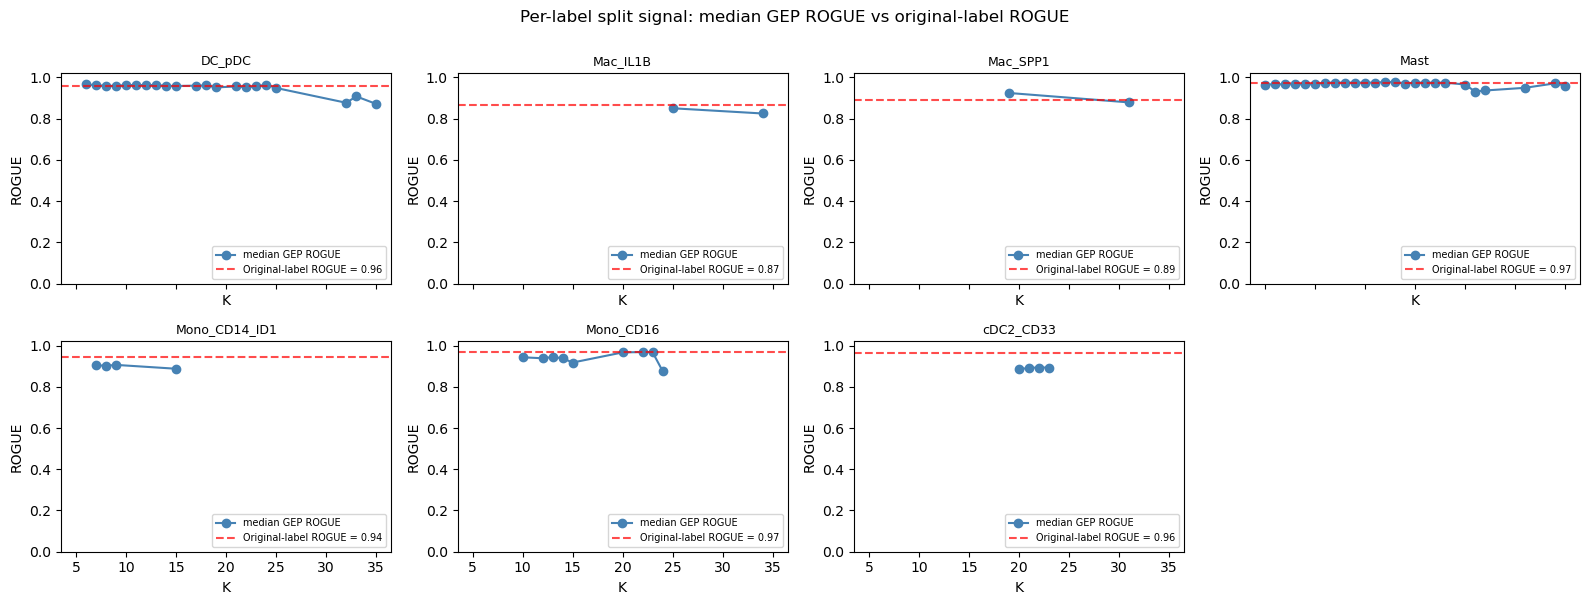

In [16]:
specific_audit = audit_df[audit_df['label_kind'] == 'specific'].copy()

per_gep_k_stats = (specific_audit
                   .groupby(['label', 'gep', 'K'])['ROGUE']
                   .agg(mean_ROGUE='mean', median_ROGUE='median',
                        max_ROGUE='max', min_ROGUE='min',
                        n_rows='count')
                   .reset_index())

baseline_by_label = (baseline_specific
                     .groupby('original_label')['ROGUE']
                     .median()
                     .to_dict())

labels_present = sorted(per_gep_k_stats['label'].unique())
n = len(labels_present)
cols = 4
rows = int(np.ceil(n / cols))
fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 3), sharex=True)
axes = np.atleast_2d(axes).ravel()

for ax, lbl in zip(axes, labels_present):
    df = per_gep_k_stats[per_gep_k_stats['label'] == lbl].sort_values('K')
    ax.plot(df['K'], df['median_ROGUE'], marker='o', color='steelblue', label='median GEP ROGUE')
    base = baseline_by_label.get(lbl, np.nan)
    if not pd.isna(base):
        ax.axhline(base, ls='--', color='red', alpha=0.7, label=f'Original-label ROGUE = {base:.2f}')
    ax.set_title(lbl, fontsize=9)
    ax.set_ylabel('ROGUE')
    ax.set_xlabel('K')
    ax.set_ylim(0, 1.02)
    ax.legend(fontsize=7, loc='lower right')

for ax in axes[n:]:
    ax.set_visible(False)

plt.suptitle("Per-label split signal: median GEP ROGUE vs original-label ROGUE", y=1.00, fontsize=12)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/per_label_split_signal.png", dpi=150, bbox_inches='tight')
plt.show()

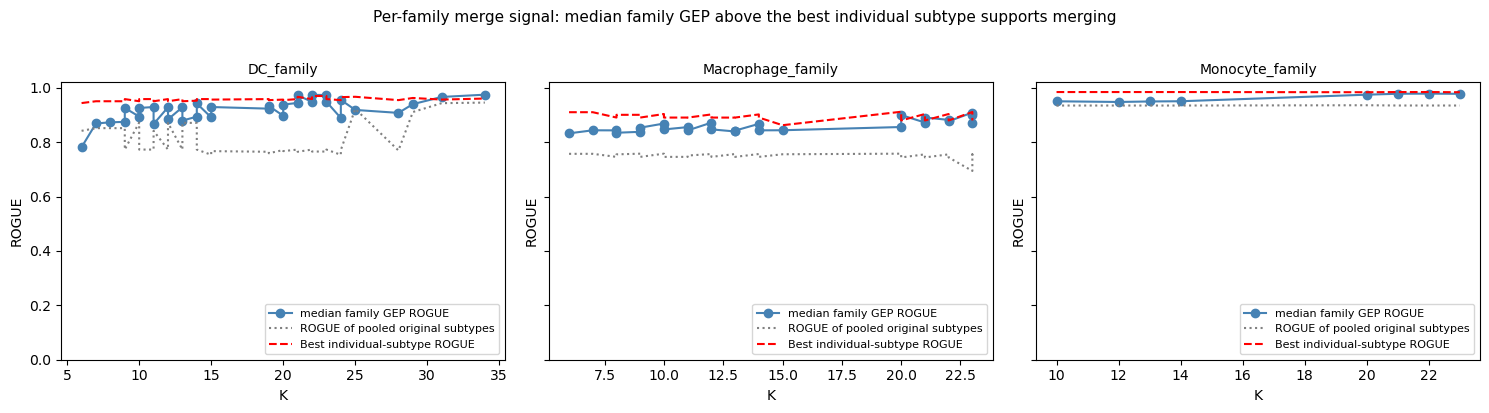

In [17]:
family_audit = audit_df[audit_df['label_kind'] == 'family'].copy()

per_gep_k_stats_family = (family_audit
                   .groupby(['label', 'gep', 'K'])
                   .agg(mean_ROGUE     =('ROGUE', 'mean'),
                        median_ROGUE   =('ROGUE', 'median'),
                        max_ROGUE      =('ROGUE', 'max'),
                        min_ROGUE      =('ROGUE', 'min'),
                        med_pool_base  =('baseline_ROGUE',      'median'),
                        med_mean_base  =('baseline_ROGUE_mean', 'median'),
                        med_max_base   =('baseline_ROGUE_max',  'median'))
                   .reset_index())

families_present = sorted(per_gep_k_stats_family['label'].unique())
n = len(families_present)
fig, axes = plt.subplots(1, n, figsize=(5 * n, 4), sharey=True)
axes = np.atleast_1d(axes)

for ax, fam_lbl in zip(axes, families_present):
    df = per_gep_k_stats_family[per_gep_k_stats_family['label'] == fam_lbl].sort_values('K')
    ax.plot(df['K'], df['median_ROGUE'],   marker='o', color='steelblue', label='median family GEP ROGUE')
    ax.plot(df['K'], df['med_pool_base'], ls=':',  color='gray', label='ROGUE of pooled original subtypes')
    ax.plot(df['K'], df['med_max_base'],  ls='--', color='red', label='Best individual-subtype ROGUE')
    ax.set_title(fam_lbl, fontsize=10)
    ax.set_xlabel('K')
    ax.set_ylabel('ROGUE')
    ax.set_ylim(0, 1.02)
    ax.legend(fontsize=8, loc='lower right')

plt.suptitle("Per-family merge signal: median family GEP above the best individual subtype supports merging", y=1.02, fontsize=11)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/per_family_merge_signal.png", dpi=150, bbox_inches='tight')
plt.show()

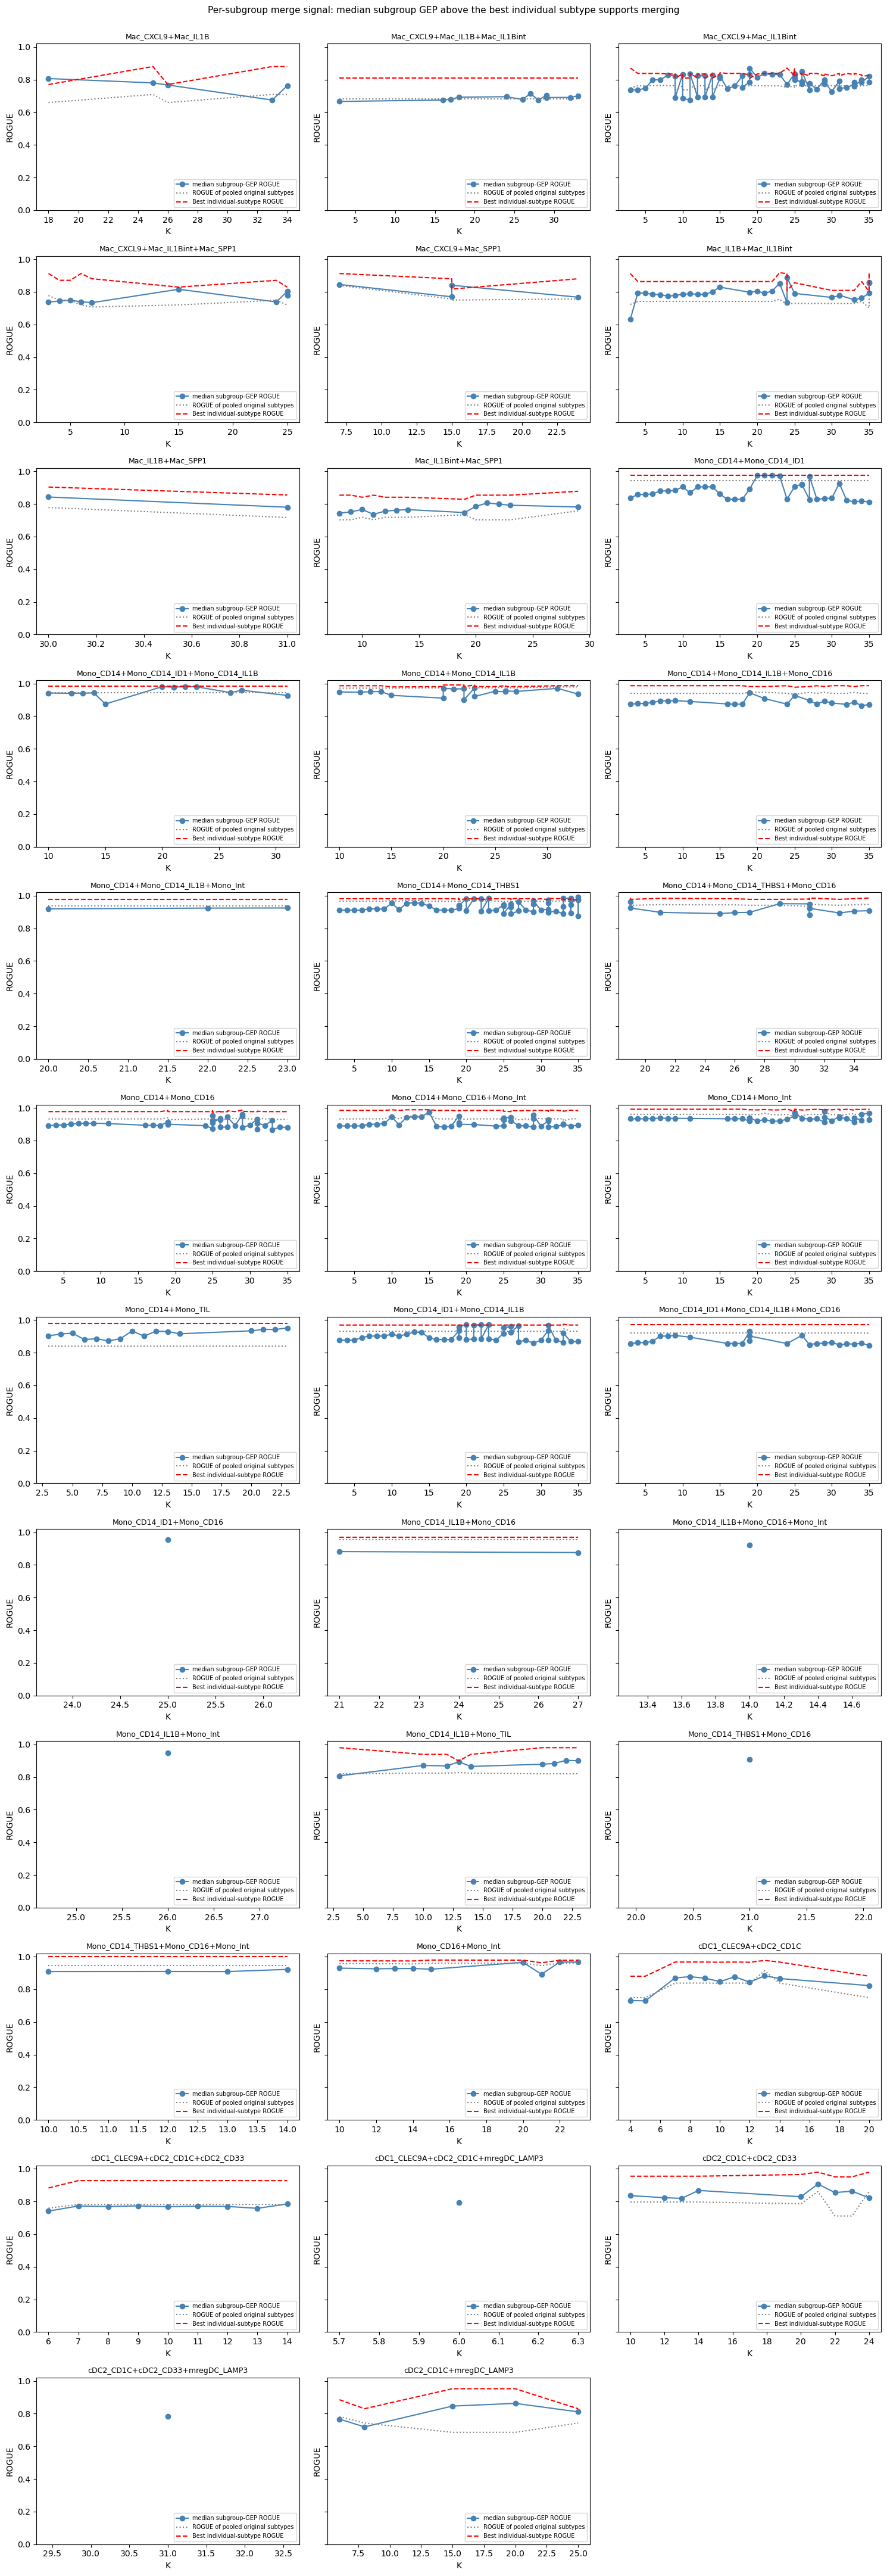

In [18]:
subgroup_audit = audit_df[audit_df['baseline_group_type'] == 'subgroup'].copy()

if len(subgroup_audit) == 0:
    print("No subgroup rows in audit_df — skipping 9c.")
else:
    per_gep_k_stats_subgroup = (subgroup_audit
                         .groupby(['membership_label', 'gep', 'K'])
                         .agg(mean_ROGUE     =('ROGUE', 'mean'),
                              median_ROGUE   =('ROGUE', 'median'),
                              max_ROGUE      =('ROGUE', 'max'),
                              min_ROGUE      =('ROGUE', 'min'),
                              med_pool_base  =('baseline_ROGUE',      'median'),
                              med_mean_base  =('baseline_ROGUE_mean', 'median'),
                              med_max_base   =('baseline_ROGUE_max',  'median'),
                              n_samples      =('sample', 'nunique'))
                         .reset_index())

    subgroups_present = sorted(per_gep_k_stats_subgroup['membership_label'].unique())
    n = len(subgroups_present)
    cols = min(3, n)
    rows = int(np.ceil(n / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 3.6), sharey=True, squeeze=False)
    axes = axes.ravel()

    for ax, sg in zip(axes, subgroups_present):
        df = per_gep_k_stats_subgroup[per_gep_k_stats_subgroup['membership_label'] == sg].sort_values('K')
        ax.plot(df['K'], df['median_ROGUE'],   marker='o', color='steelblue', label='median subgroup-GEP ROGUE')
        ax.plot(df['K'], df['med_pool_base'], ls=':',  color='gray', label='ROGUE of pooled original subtypes')
        ax.plot(df['K'], df['med_max_base'],  ls='--', color='red', label='Best individual-subtype ROGUE')
        ax.set_title(sg, fontsize=9)
        ax.set_xlabel('K')
        ax.set_ylabel('ROGUE')
        ax.set_ylim(0, 1.02)
        ax.legend(fontsize=7, loc='lower right')

    for ax in axes[n:]:
        ax.set_visible(False)

    plt.suptitle("Per-subgroup merge signal: median subgroup GEP above the best individual subtype supports merging", y=1.00, fontsize=11)
    plt.tight_layout()
    plt.savefig(f"{OUT_DIR}/per_subgroup_merge_signal.png", dpi=150, bbox_inches='tight')
    plt.show()

#### 10. Per-label aggregate

Collapses `audit_df` to one row per `membership_label`: its baseline ROGUE (median across samples) and, for subgroup/family rows, `median_best_constituent` — the baseline of the best individual subtype it needs to beat. `n_K_with_signal` counts distinct K values where the strict bar (Δ vs max for subgroup/family, Δ vs baseline for specific) was cleared — the persistence-across-K check. Saved to `rogue_per_label_aggregate.csv`.

In [19]:
def _per_label_aggregate(df, kind):
    """One row per membership_label: baseline is nb6 (specific), nb6b (family),
    or nb7c (subgroup)."""
    rows = []
    for lbl, sub in df.groupby('membership_label'):
        if sub['ROGUE'].notna().sum() == 0:
            continue
        members_str = sub['members_str'].iloc[0]

        median_best_constituent = np.nan

        if kind == 'specific':
            base_median = (baseline_specific[baseline_specific['original_label'] == lbl]
                           ['ROGUE'].median())

        elif kind == 'family':
            base_median = (baseline_family[baseline_family['family_label'] == lbl]
                           ['ROGUE'].median())
            fam = lbl[:-len(FAMILY_LABEL_SUFFIX)]
            family_members = CELLTYPE_FAMILIES.get(fam, [])
            constituent_max_medians = []
            for s in sub['sample'].unique():
                vals = [baseline_specific_lookup.get((s, m)) for m in family_members]
                vals = [v for v in vals if v is not None and not np.isnan(v)]
                if vals:
                    constituent_max_medians.append(max(vals))
            median_best_constituent = (float(np.median(constituent_max_medians))
                                       if constituent_max_medians else np.nan)

        elif kind == 'subgroup':
            base_vals = (baseline_subgroup
                         [baseline_subgroup['members_str'] == lbl]['ROGUE']
                         .dropna())
            base_median = float(base_vals.median()) if len(base_vals) else np.nan
            sub_members = lbl.split('+')
            constituent_max_medians = []
            for s in sub['sample'].unique():
                vals = [baseline_specific_lookup.get((s, m)) for m in sub_members]
                vals = [v for v in vals if v is not None and not np.isnan(v)]
                if vals:
                    constituent_max_medians.append(max(vals))
            median_best_constituent = (float(np.median(constituent_max_medians))
                                       if constituent_max_medians else np.nan)

        else:
            base_median = np.nan

        if kind == 'specific':
            sig = sub[sub.get('delta_ROGUE', np.nan).fillna(-np.inf)
                      >= DELTA_ROGUE_THRESHOLD]
        else:
            sig = sub[sub.get('delta_ROGUE_vs_max', np.nan).fillna(-np.inf)
                      >= DELTA_ROGUE_THRESHOLD]
        n_K_with_signal = sig['K'].nunique()

        row = {
            'label':                  lbl,
            'membership_label':        lbl,
            'label_kind':             kind,
            'baseline_group_type':         kind,
            'members_str':            members_str,
            'baseline_ROGUE_median':  base_median,
            'median_best_constituent': median_best_constituent,
            'n_K_with_signal':        n_K_with_signal,
            'n_rows':                 len(sub),
        }
        if kind in ('family', 'subgroup'):
            row['median_best_constituent_baseline'] = median_best_constituent
        rows.append(row)
    return pd.DataFrame(rows)


per_label_specific = _per_label_aggregate(
    audit_df[audit_df['baseline_group_type'] == 'specific'], 'specific')
per_label_subgroup = _per_label_aggregate(
    audit_df[audit_df['baseline_group_type'] == 'subgroup'], 'subgroup')
per_label_family   = _per_label_aggregate(
    audit_df[audit_df['baseline_group_type'] == 'family'],   'family')

per_label_agg = pd.concat([per_label_specific, per_label_subgroup, per_label_family],
                          ignore_index=True, sort=False)

out = os.path.join(OUT_DIR, "rogue_per_label_aggregate.csv")
per_label_agg.to_csv(out, index=False)
print(f"Saved per-label aggregate → {out}")
print(f"\nRow counts by baseline_group_type:")
print(per_label_agg['baseline_group_type'].value_counts().to_string())
per_label_agg

Saved per-label aggregate → rogue_purity_results_per_gep/rogue_per_label_aggregate.csv

Row counts by baseline_group_type:
baseline_group_type
subgroup    35
specific     7
family       3


,label,membership_label,label_kind,baseline_group_type,members_str,baseline_ROGUE_median,median_best_constituent,n_K_with_signal,n_rows,median_best_constituent_baseline
0,DC_pDC,DC_pDC,specific,specific,DC_pDC,0.959734,NaN,1,661,NaN
1,Mac_IL1B,Mac_IL1B,specific,specific,Mac_IL1B+Mac_IL1Bint+Mono_TIL,0.867614,NaN,0,25,NaN
2,Mac_SPP1,Mac_SPP1,specific,specific,Mac_SPP1,0.890166,NaN,1,37,NaN
3,Mast,Mast,specific,specific,Mast,0.974814,NaN,4,159,NaN
4,Mono_CD14_ID1,Mono_CD14_ID1,specific,specific,Mono_CD14,0.943463,NaN,0,147,NaN
5,Mono_CD16,Mono_CD16,specific,specific,Mono_CD16+Mono_Int+cDC2_CD33,0.969665,NaN,2,208,NaN
6,cDC2_CD33,cDC2_CD33,specific,specific,Mono_CD14_ID1,0.962459,NaN,0,157,NaN
7,Mac_CXCL9+Mac_IL1B,Mac_CXCL9+Mac_IL1B,subgroup,subgroup,Mac_CXCL9+Mac_IL1B,0.684285,0.824967,0,5,0.824967
8,Mac_CXCL9+Mac_IL1B+Mac_IL1Bint,Mac_CXCL9+Mac_IL1B+Mac_IL1Bint,subgroup,subgroup,Mac_CXCL9+Mac_IL1B+Mac_IL1Bint,0.681656,0.808684,0,12,0.808684
9,Mac_CXCL9+Mac_IL1Bint,Mac_CXCL9+Mac_IL1Bint,subgroup,subgroup,Mac_CXCL9+Mac_IL1Bint,0.758434,0.841477,1,153,0.841477


#### 11. Distribution per label and per sample

For every label, `ROGUE_*` / `delta_ROGUE_*` (min/median/max/IQR) are computed across every (sample, K, GEP) row carrying that label, so a "purer" call backed by a tight, consistently high distribution can be told apart from one backed by a single outlier and a long tail of ties. A boxplot per `baseline_group_type` then shows each sample's own raw ROGUE distribution (quartiles), split into the same specific/subgroup/family panels.

In [20]:
def _iqr(s):
    q1, q3 = s.quantile([0.25, 0.75])
    return q3 - q1

dist_rogue = (audit_df.groupby(['baseline_group_type', 'membership_label'])['ROGUE']
              .agg(ROGUE_min='min', ROGUE_median='median', ROGUE_max='max', ROGUE_iqr=_iqr)
              .reset_index())

dist_delta = (audit_df.dropna(subset=['delta_ROGUE'])
              .groupby(['baseline_group_type', 'membership_label'])['delta_ROGUE']
              .agg(delta_ROGUE_min='min', delta_ROGUE_median='median',
                   delta_ROGUE_max='max', delta_ROGUE_iqr=_iqr)
              .reset_index())

per_label_agg = (per_label_agg
                 .merge(dist_rogue, on=['baseline_group_type', 'membership_label'], how='left')
                 .merge(dist_delta, on=['baseline_group_type', 'membership_label'], how='left'))

out = os.path.join(OUT_DIR, "rogue_per_label_aggregate.csv")
per_label_agg.to_csv(out, index=False)
print(f"Added ROGUE/delta_ROGUE distribution stats → {out}")
per_label_agg[['membership_label', 'baseline_group_type',
               'ROGUE_min', 'ROGUE_median', 'ROGUE_max', 'ROGUE_iqr',
               'delta_ROGUE_min', 'delta_ROGUE_median', 'delta_ROGUE_max', 'delta_ROGUE_iqr']].head(15)

Added ROGUE/delta_ROGUE distribution stats → rogue_purity_results_per_gep/rogue_per_label_aggregate.csv


,membership_label,baseline_group_type,ROGUE_min,ROGUE_median,ROGUE_max,ROGUE_iqr,delta_ROGUE_min,delta_ROGUE_median,delta_ROGUE_max,delta_ROGUE_iqr
0,DC_pDC,specific,0.610596,0.950858,1.000000,0.066357,-0.307067,0.000000,0.072178,0.013407
1,Mac_IL1B,specific,0.680886,0.861981,1.000000,0.098606,-0.142367,-0.052361,-0.004097,0.080481
2,Mac_SPP1,specific,0.668849,0.930746,0.981586,0.080556,-0.185062,-0.039818,0.071240,0.132158
3,Mast,specific,0.872495,0.970097,1.000000,0.042364,-0.072343,0.000000,0.072486,0.001094
4,Mono_CD14_ID1,specific,0.708112,0.895311,1.000000,0.068643,-0.054770,-0.040441,-0.040441,0.003582
5,Mono_CD16,specific,0.637707,0.954523,1.000000,0.072947,-0.171746,-0.022624,0.076772,0.056289
6,cDC2_CD33,specific,0.726230,0.884336,1.000000,0.054893,-0.225282,-0.071501,-0.009243,0.033958
7,Mac_CXCL9+Mac_IL1B,subgroup,0.674771,0.766905,0.806414,0.017038,-0.034267,0.070907,0.146881,0.053503
8,Mac_CXCL9+Mac_IL1B+Mac_IL1Bint,subgroup,0.666100,0.690638,0.714128,0.018976,-0.015555,0.008982,0.032472,0.018976
9,Mac_CXCL9+Mac_IL1Bint,subgroup,0.675385,0.808223,0.916300,0.058079,-0.066895,0.036238,0.195684,0.054704


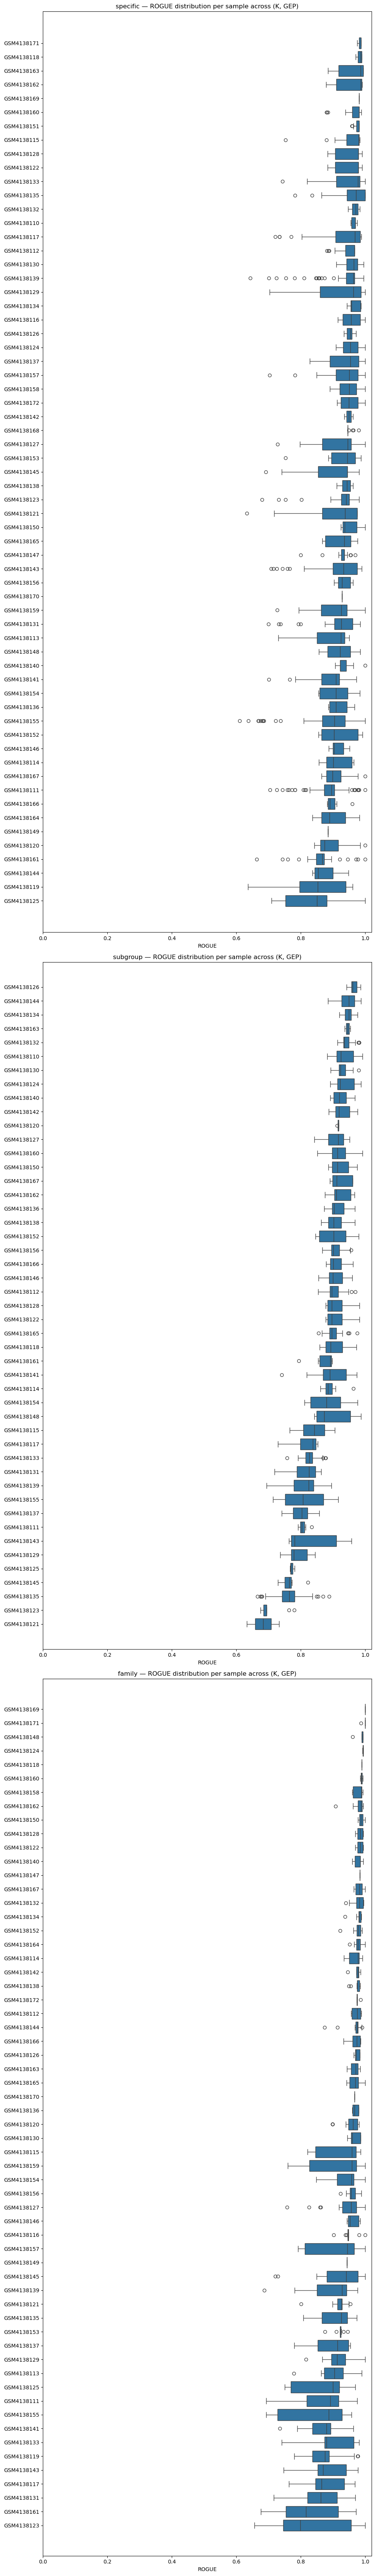

In [21]:
kinds = ['specific', 'subgroup', 'family']
panels = []
for kind in kinds:
    sub = audit_df[(audit_df['baseline_group_type'] == kind) & audit_df['ROGUE'].notna()]
    if len(sub) > 0:
        panels.append((kind, sub))

if not panels:
    print("No rows with a computed ROGUE — skipping boxplot.")
else:
    # Give each panel height proportional to its own sample count (not an
    # equal split of the total), and more room per sample, so y labels don't crowd.
    sample_counts = [sub['sample'].nunique() for _, sub in panels]
    row_heights = [max(2, 0.4 * n) for n in sample_counts]

    fig, axes = plt.subplots(
        len(panels), 1,
        figsize=(10, sum(row_heights)),
        gridspec_kw={'height_ratios': row_heights},
        squeeze=False,
    )
    axes = axes.ravel()

    for ax, (kind, sub) in zip(axes, panels):
        order = (sub.groupby('sample')['ROGUE']
                    .median().sort_values(ascending=False).index)
        sns.boxplot(data=sub, y='sample', x='ROGUE', order=order, ax=ax)
        ax.margins(y=0.03)
        ax.set_xlim(0, 1.02)
        ax.set_title(f'{kind} — ROGUE distribution per sample across (K, GEP)')
        ax.set_xlabel('ROGUE')
        ax.set_ylabel('')

    plt.tight_layout()
    plt.savefig(f"{OUT_DIR}/rogue_distribution_boxplot.png", dpi=150, bbox_inches='tight')
    plt.show()